In [25]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as tt
from torch.utils.data import random_split
from torchvision.utils import make_grid
import matplotlib
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
img_h, img_w = (224, 224)
channels = 3

In [28]:
transform = transforms.Compose([
    transforms.Resize((img_h, img_w)),
    transforms.ToTensor(),
])

In [29]:
data_root = '/content/drive/MyDrive/Airplane_Mini_Datasets_Collation/'

# Create ImageFolder datasets for Train, Validation, and Test sets
train_dataset = datasets.ImageFolder(root=data_root + 'Train', transform=transform)
val_dataset = datasets.ImageFolder(root=data_root + 'Validation', transform=transform)
test_dataset = datasets.ImageFolder(root=data_root + 'Test', transform=transform)

In [30]:
print("No of images in Training dataset:    ",len(train_dataset))
print("No of images in Testing dataset:     ",len(test_dataset))
print("No of images in Validation dataset:     ",len(val_dataset))

No of images in Training dataset:     3608
No of images in Testing dataset:      1263
No of images in Validation dataset:      390


In [31]:
l = train_dataset.classes
print("No of classes: ",len(l))
print("List of all classes\n", l)

No of classes:  13
List of all classes
 ['Airbus-A220', 'Airbus-A300', 'Airbus-A310', 'Airbus-A320', 'Airbus-A330', 'Airbus-A350', 'Airbus-A380', 'Boeing-B707', 'Boeing-B727', 'Boeing-B737', 'Boeing-B767', 'Boeing-B777', 'Boeing-B787']


In [32]:
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [33]:
class_names = train_dataset.classes
def idx_to_label(idx):
    return class_names[idx]

In [34]:
def show_example(data):
    img, label = data
    print("Label: ("+idx_to_label(label)+")")
    plt.imshow(img.permute(1, 2, 0))

Label: (Airbus-A220)


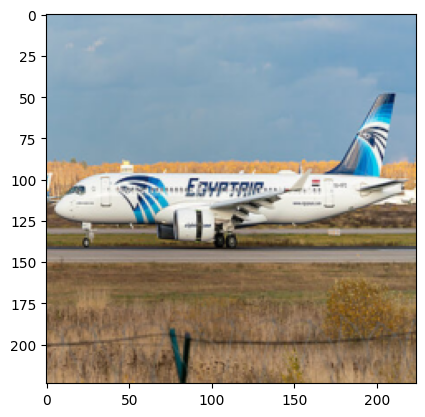

In [35]:
show_example(train_dataset[0])

Label: (Airbus-A330)


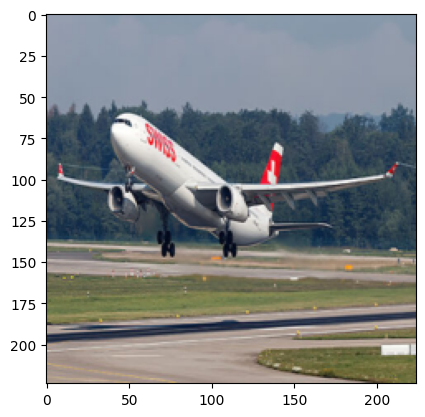

In [36]:
show_example(train_dataset[1230])

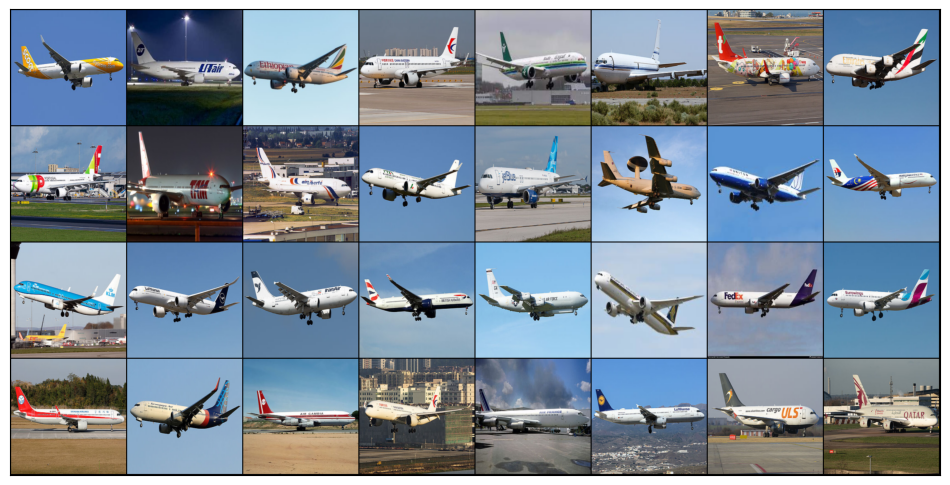

In [37]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 12))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=8).permute(1, 2, 0))
        break

show_batch(train_dataloader)

In [38]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [39]:
# Returns current working runtype

device = get_default_device()
device

device(type='cuda')

In [40]:
# Lets transfer the training dataloader and validation dataloader to CUDA if available

train_dl = DeviceDataLoader(train_dataloader, device)
val_dl = DeviceDataLoader(val_dataloader, device)
test_dl = DeviceDataLoader(test_dataloader, device)

In [41]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    actual = []
    predicted = []
    for batch in val_loader:
        image, label = batch
        actual.extend(to_device(label, "cpu"))
        _, preds = torch.max(model.batch_prediction(image), dim=1)
        predicted.extend(to_device(preds, "cpu"))

    result = model.validation_epoch_end(outputs)
    result['confusion_matrix'] = confusion_matrix(actual, predicted)
    return result

In [42]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def fit_one_cycle(epochs, max_lr, model, train_loader, val_loader,
                  weight_decay=0, grad_clip=None, opt_func=torch.optim.SGD):
    torch.cuda.empty_cache()
    history = []

    optimizer = opt_func(model.parameters(), max_lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs,
                                                steps_per_epoch=len(train_loader))

    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        lrs = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()

            # Gradient clipping
            if grad_clip:
                nn.utils.clip_grad_value_(model.parameters(), grad_clip)

            optimizer.step()
            optimizer.zero_grad()

            # Record & update learning rate
            lrs.append(get_lr(optimizer))
            sched.step()

        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        result['lrs'] = lrs
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [43]:
class AeroplaneClassificationBase(nn.Module):
    def batch_prediction(self, batch_images):
        out = self(batch_images)
        return out

    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch [{}], last_lr: {:.5f}, train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch, result['lrs'][-1], result['train_loss'], result['val_loss'], result['val_acc']))

class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        residual = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += self.shortcut(residual)
        out = self.relu(out)

        return out

class GeneralizedResNet(AeroplaneClassificationBase):
    def __init__(self, block, layers, in_channels, num_classes, name="ResNet"):
        super(GeneralizedResNet, self).__init__()

        self.name = name

        self.in_channels = 64
        self.conv1 = nn.Conv2d(in_channels, self.in_channels, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Residual blocks
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        # Adaptive pooling layer
        self.adaptive_pool = nn.AdaptiveAvgPool2d(1)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, num_classes)
        )

    def _make_layer(self, block, out_channels, blocks, stride=1):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels  # Update in_channels for the next layer
        for _ in range(1, blocks):
            layers.append(block(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.adaptive_pool(out)
        out = self.classifier(out)

        return out

In [44]:
# Create ResNet18
def ResNet18(in_channels, num_classes):
    return GeneralizedResNet(BasicBlock, [2, 2, 2, 2], in_channels, num_classes, "ResNet18")


model_rn18 = to_device(ResNet18(3, len(class_names)), device)
model_rn18

GeneralizedResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

In [45]:
# Create ResNet50
def ResNet50(in_channels, num_classes):
    return GeneralizedResNet(BasicBlock, [3, 4, 6, 3], in_channels, num_classes, "ResNet50")

model_rn50 = to_device(ResNet50(3, len(class_names)), device)
model_rn50

GeneralizedResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

ResNet 18: 	 Accuracy=0.07266 	 Loss=2.56535
ResNet 50: 	 Accuracy=0.08828 	 Loss=2.56475


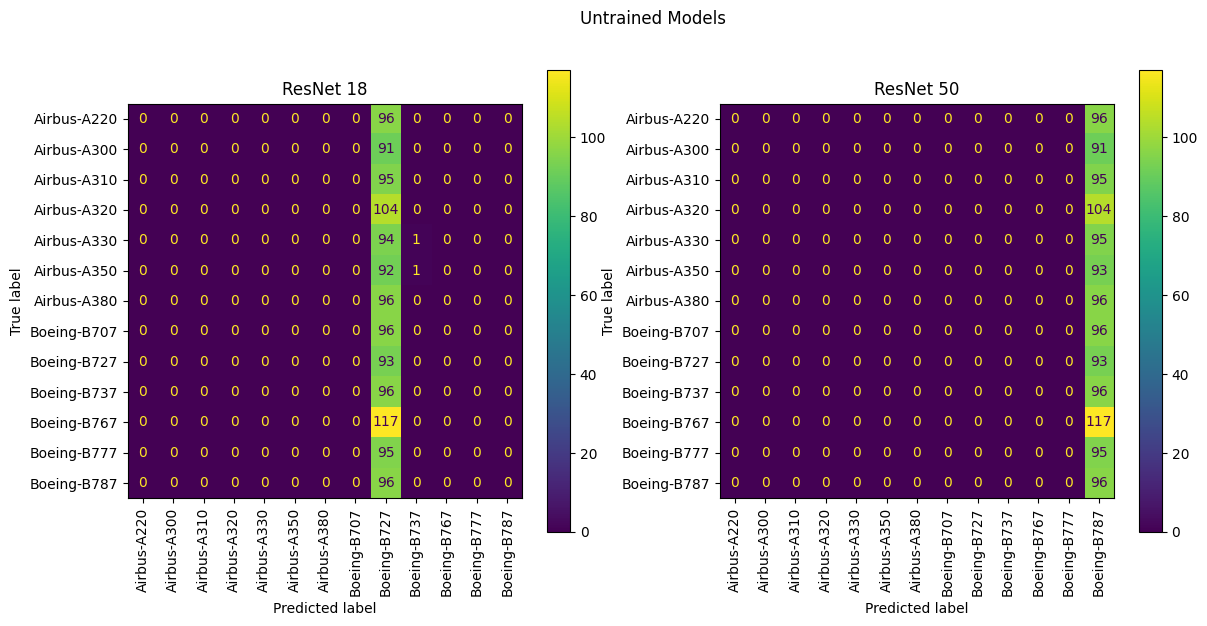

In [46]:
rn18_result = evaluate(model_rn18, test_dl)
rn50_result = evaluate(model_rn50, test_dl)

print(f"ResNet 18: \t Accuracy={round(rn18_result['val_acc'], 5)} \t Loss={round(rn18_result['val_loss'], 5)}")
print(f"ResNet 50: \t Accuracy={round(rn50_result['val_acc'], 5)} \t Loss={round(rn50_result['val_loss'], 5)}")

rn18_cm = rn18_result['confusion_matrix']
rn50_cm = rn50_result['confusion_matrix']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rn18_disp = ConfusionMatrixDisplay(confusion_matrix=rn18_cm, display_labels=class_names)
rn50_disp = ConfusionMatrixDisplay(confusion_matrix=rn50_cm, display_labels=class_names)
rn18_disp.plot(ax=axes[0])
rn50_disp.plot(ax=axes[1])

axes[0].set_title("ResNet 18")
axes[1].set_title("ResNet 50")

for ax in axes:
    ax.tick_params(axis='x', rotation=90)

plt.suptitle("Untrained Models")

plt.show()

In [47]:
def add_result(model, epochs, max_lr, grad_clip, weight_decay, opt_func):
    existing = pd.read_csv("result.csv")
    model_result = evaluate(model, test_dl)
    result = dict()
    result["model"] = [model.name]
    result["epochs"] = [epochs]
    result["max_lr"] = [max_lr]
    result["grad_clip"] = [grad_clip]
    result["weight_decay"] = [weight_decay]
    result["opt_func"] = [opt_func.__name__]
    result["img_h"] = [img_h]
    result["img_w"] = [img_w]
    result["test_loss"] = [model_result["val_loss"]]
    result["test_acc"] = [model_result["val_acc"]]
    result_df = pd.DataFrame.from_dict(result)


In [48]:
epochs = 70
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-6
opt_func = torch.optim.Adam

model_rn18 = to_device(ResNet18(3, len(class_names)), device)
model_rn50 = to_device(ResNet50(3, len(class_names)), device)


history_rn50 = fit_one_cycle(epochs, max_lr, model_rn50, train_dl, val_dl,
                            grad_clip=grad_clip,
                            weight_decay=weight_decay,
                            opt_func=opt_func)

history_rn18= fit_one_cycle(epochs, max_lr, model_rn18, train_dl, val_dl,
                            grad_clip=grad_clip,
                            weight_decay=weight_decay,
                            opt_func=opt_func)




Epoch [0], last_lr: 0.00045, train_loss: 2.2574, val_loss: 2.9254, val_acc: 0.1394
Epoch [1], last_lr: 0.00061, train_loss: 1.9983, val_loss: 2.4687, val_acc: 0.2139
Epoch [2], last_lr: 0.00087, train_loss: 1.8485, val_loss: 16.6696, val_acc: 0.0769
Epoch [3], last_lr: 0.00123, train_loss: 1.7788, val_loss: 3.3336, val_acc: 0.1194
Epoch [4], last_lr: 0.00168, train_loss: 1.7170, val_loss: 2.4185, val_acc: 0.2596
Epoch [5], last_lr: 0.00220, train_loss: 1.7117, val_loss: 6.7789, val_acc: 0.0913
Epoch [6], last_lr: 0.00280, train_loss: 1.6113, val_loss: 2.8764, val_acc: 0.2452
Epoch [7], last_lr: 0.00344, train_loss: 1.4406, val_loss: 4.7021, val_acc: 0.1779
Epoch [8], last_lr: 0.00413, train_loss: 1.3704, val_loss: 10.0709, val_acc: 0.1082
Epoch [9], last_lr: 0.00484, train_loss: 1.2533, val_loss: 3.5304, val_acc: 0.2668
Epoch [10], last_lr: 0.00556, train_loss: 1.1492, val_loss: 4.9799, val_acc: 0.1643
Epoch [11], last_lr: 0.00627, train_loss: 1.0292, val_loss: 2.4700, val_acc: 0.4014


ResNet 18: 	 Accuracy=0.60333 	 Loss=2.89005
ResNet 50: 	 Accuracy=0.57432 	 Loss=3.61345


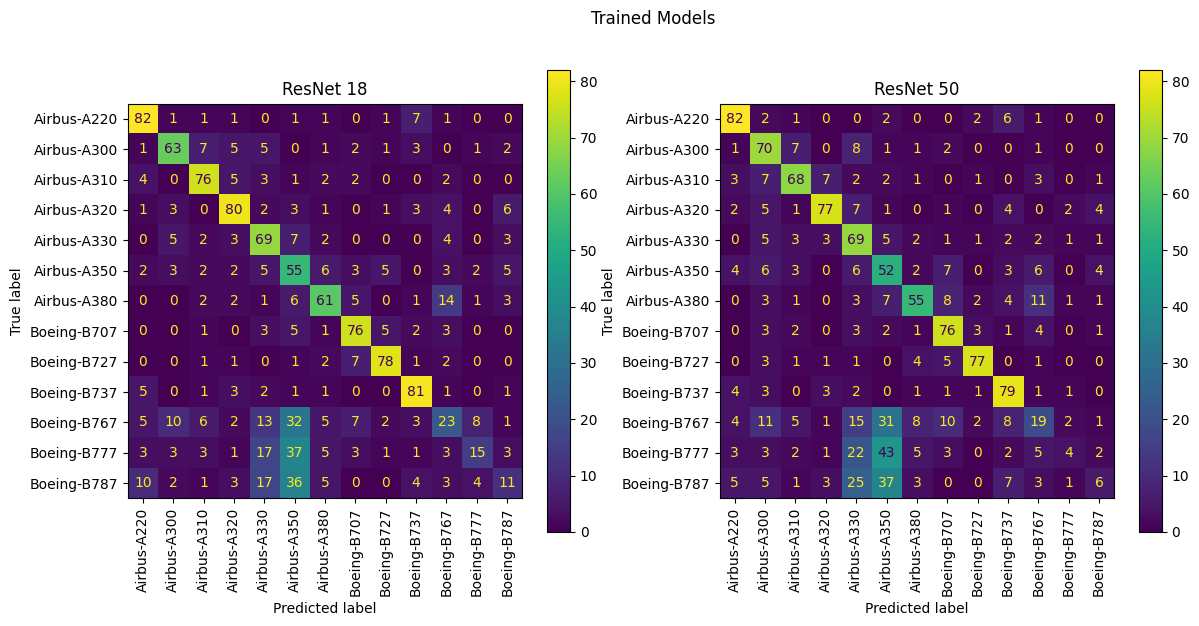

In [49]:
rn18_result = evaluate(model_rn18, test_dl)
rn50_result = evaluate(model_rn50, test_dl)

print(f"ResNet 18: \t Accuracy={round(rn18_result['val_acc'], 5)} \t Loss={round(rn18_result['val_loss'], 5)}")
print(f"ResNet 50: \t Accuracy={round(rn50_result['val_acc'], 5)} \t Loss={round(rn50_result['val_loss'], 5)}")

rn18_cm = rn18_result['confusion_matrix']
rn50_cm = rn50_result['confusion_matrix']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rn18_disp = ConfusionMatrixDisplay(confusion_matrix=rn18_cm, display_labels=class_names)
rn50_disp = ConfusionMatrixDisplay(confusion_matrix=rn50_cm, display_labels=class_names)
rn18_disp.plot(ax=axes[0])
rn50_disp.plot(ax=axes[1])

axes[0].set_title("ResNet 18")
axes[1].set_title("ResNet 50")

for ax in axes:
    ax.tick_params(axis='x', rotation=90)

plt.suptitle("Trained Models")

plt.show()

In [50]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

def plot_lrs(history):
    lrs = np.concatenate([x.get('lrs', []) for x in history])
    plt.plot(lrs)
    plt.xlabel('Batch no.')
    plt.ylabel('Learning rate')
    plt.title('Learning Rate vs. Batch no.');

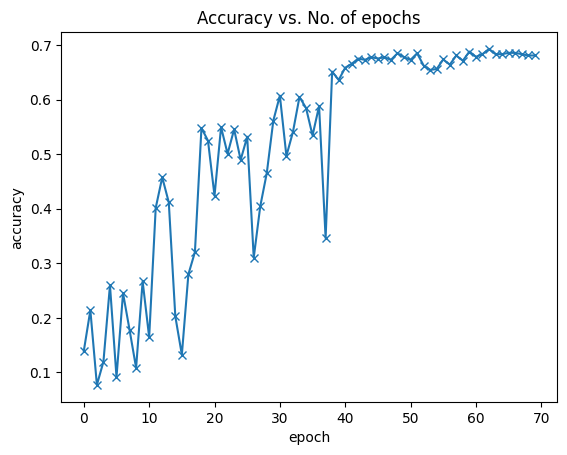

In [51]:
plot_accuracies(history_rn50)

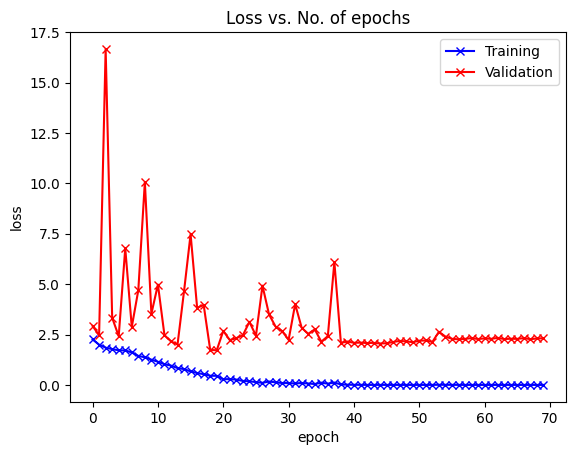

In [52]:
plot_losses(history_rn50)

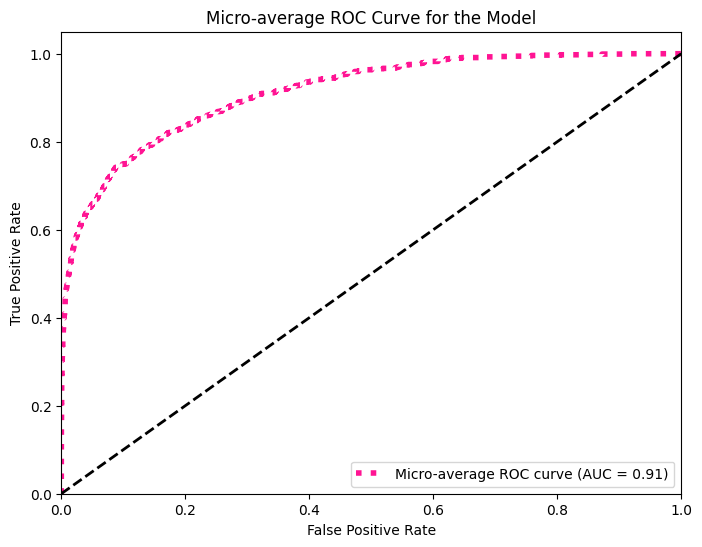

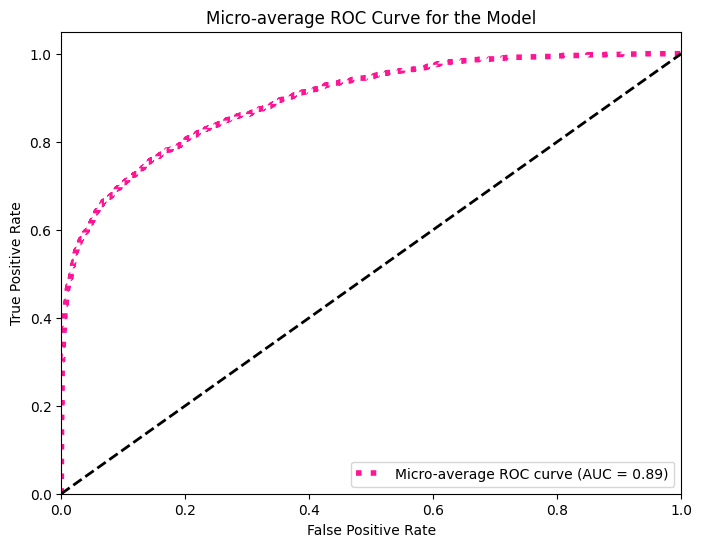

In [54]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt

def plot_roc_curve(model, dataloader, num_classes):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model.batch_prediction(images)
            all_labels.extend(to_device(labels, 'cpu'))
            all_probs.extend(to_device(F.softmax(outputs, dim=1), 'cpu'))

    all_labels = label_binarize(all_labels, classes=list(range(num_classes)))
    all_probs = torch.stack(all_probs, dim=0).numpy()

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calculate ROC curve for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Compute micro-average ROC curve and ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(all_labels.ravel(), all_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Plot micro-average ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f'Micro-average ROC curve (AUC = {roc_auc["micro"]:.2f})',
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Micro-average ROC Curve for the Model')
    plt.legend(loc="lower right")
    plt.show()

# Plot micro-average ROC curves and calculate AUC for ResNet18
plot_roc_curve(model_rn18, test_dl, len(class_names))

# Plot micro-average ROC curves and calculate AUC for ResNet50
plot_roc_curve(model_rn50, test_dl, len(class_names))



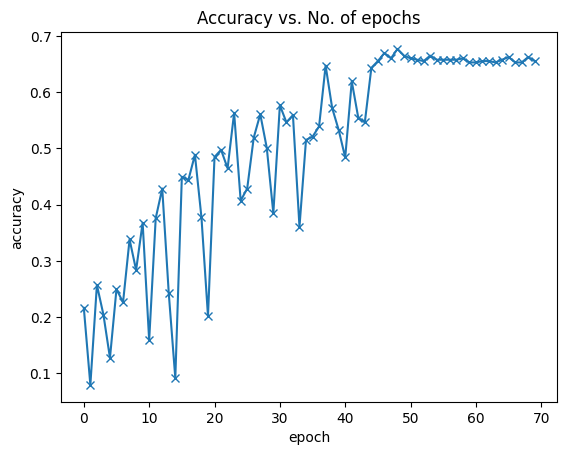

In [55]:
plot_accuracies(history_rn18)

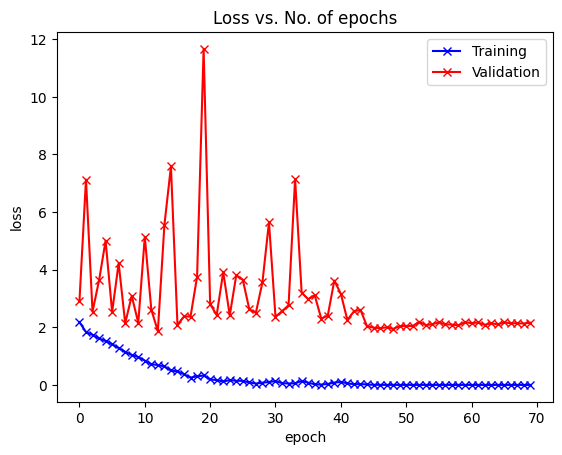

In [56]:
plot_losses(history_rn18)

In [58]:
from sklearn.metrics import confusion_matrix

def get_predictions_and_labels(model, dataloader):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in dataloader:
            outputs = model.batch_prediction(images)
            _, preds = torch.max(outputs, dim=1)
            all_labels.extend(to_device(labels, 'cpu'))
            all_preds.extend(to_device(preds, 'cpu'))

    return np.array(all_labels), np.array(all_preds)

# Get labels and predictions for ResNet18
labels_rn18, predictions_rn18 = get_predictions_and_labels(model_rn18, test_dl)
rn18_conf_matrix = confusion_matrix(labels_rn18, predictions_rn18)
metrics_rn18 = calculate_metrics_from_confusion_matrix(rn18_conf_matrix)

# Get labels and predictions for ResNet50
labels_rn50, predictions_rn50 = get_predictions_and_labels(model_rn50, test_dl)
rn50_conf_matrix = confusion_matrix(labels_rn50, predictions_rn50)
metrics_rn50 = calculate_metrics_from_confusion_matrix(rn50_conf_matrix)

print("Metrics for ResNet18:")
print(metrics_rn18)

print("\nMetrics for ResNet50:")
print(metrics_rn50)



Metrics for ResNet18:
{'precision': 0.984375, 'recall': 0.984375, 'specificity': 0.9879518072289156, 'f1_score': 0.984375}

Metrics for ResNet50:
{'precision': 0.9722222222222222, 'recall': 0.9859154929577465, 'specificity': 0.9761904761904762, 'f1_score': 0.979020979020979}


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed